# Notebook 14 — Curve-of-growth R_e reconciliation (Task 4, 2026-06-08)

**Question (HANDOFF Tier-1 #4):** `measure_Re.hst_Re` reported F200LP R_e = **1.91"** while
`final_sigma_e.curve_of_growth` (which sets the **headline R_e = 2.305"**) reports **2.44"** for the
same band — a ~0.5" disagreement *at the same pixel scale*. Reconcile the two algorithms and decide
which is canonical.

**Findings (this notebook):**
1. **The two CoG algorithms agree to <0.04" when `r_max` is matched.** The entire 0.5" gap is that
   `measure_Re.hst_Re` capped the radial profile at `arange(1,80,1)` px = **4.0"** (F200LP), while
   `final_sigma_e.curve_of_growth` integrates to **6.0"**. Truncating early under-integrates the
   outer light and biases R_e *low*. -> Fixed: `hst_Re` now takes `r_max_arcsec=6.0` by default.
2. **A raw (sky-unsubtracted) CoG R_e does NOT converge** -- it climbs monotonically with `r_max`
   (F200LP 2.44"->5.10" over r_max 6->12"). The headline 2.305" is effectively a *choice* of r_max=6".
3. Median-sky subtraction (10-14" annulus) helps but does not fully flatten the CoG either.
4. The **Sersic analytic R_eff** (single-Sersic fits, `sersic_total_photometry.npz`) anchors
   F200LP 2.49" / F140W 1.88" (mean 2.18"); sky-sub CoG at r_max=6" gives ~2.1-2.2".
   -> The headline 2.305" sits at the **upper end** of a ~2.1-2.5" family. **R_e systematic ~ +-0.1-0.2"
   (~5-9%)**, documented here; **headline left unchanged** (changing it propagates to the sigma_e
   aperture and M*, a separate decision flagged for the user).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import os
_p = Path.cwd()
REPO = _p.parent if _p.name == 'notebooks' else _p
os.chdir(REPO); sys.path.insert(0, str(REPO))
import scripts.measure_Re as mre
import scripts.final_sigma_e as fse
from photutils.aperture import CircularAnnulus, ApertureStats

BANDS = ['F200LP', 'F140W']
imgs = {}
for b in BANDS:
    info = mre.HST_FILES[b]
    with fits.open(info['image']) as h:
        img = h[0].data.astype(float); wcs = WCS(h[0].header)
    mask = fits.getdata(info['mask']).astype(bool)
    pscale = float(np.abs(proj_plane_pixel_scales(wcs)[0])) * 3600
    xc, yc = fse.find_center(img, mask, wcs, fse.RA_DEFL, fse.DEC_DEFL, pix_scale=pscale)
    xw, yw = wcs.world_to_pixel_values(mre.RA_CENTER, mre.DEC_CENTER)
    imgs[b] = dict(img=img, wcs=wcs, mask=mask, pscale=pscale,
                   cen_centroid=(float(xc), float(yc)), cen_world=(float(xw), float(yw)))
    print(f'{b}: pscale={pscale:.4f}\"/pix  mask={mask.sum()} px  '
          f'centroid=({xc:.1f},{yc:.1f})  world=({float(xw):.1f},{float(yw):.1f})  '
          f'dcen={np.hypot(xc-float(xw),yc-float(yw))*pscale:.3f}\"')

F200LP: pscale=0.0500"/pix  mask=2512 px  centroid=(246.6,254.1)  world=(249.5,249.7)  dcen=0.264"
F140W: pscale=0.0800"/pix  mask=1121 px  centroid=(156.0,154.9)  world=(155.2,155.8)  dcen=0.093"


## 1. Baseline disagreement, then matched-`r_max` reconciliation

In [2]:
print('BASELINE (as-shipped):')
for b in BANDS:
    d = imgs[b]
    r_mre = mre.hst_Re(b, masking='proper', r_max_arcsec=4.0)['Re']
    r_fse = fse.curve_of_growth(d['img'], d['cen_centroid'], d['pscale'], mask=d['mask'], r_max=6.0)
    print(f'  {b}:  measure_Re(r_max=4.0\") = {r_mre:.3f}\"   '
          f'final_sigma_e(r_max=6.0\") = {r_fse:.3f}\"   d={r_fse-r_mre:+.3f}\"')

print('\nMATCHED r_max (both at 6.0\", centroid center):')
for b in BANDS:
    d = imgs[b]
    r_mre6 = mre.hst_Re(b, masking='proper', r_max_arcsec=6.0)['Re']
    r_fse6 = fse.curve_of_growth(d['img'], d['cen_centroid'], d['pscale'], mask=d['mask'], r_max=6.0)
    print(f'  {b}:  measure_Re = {r_mre6:.3f}\"   final_sigma_e = {r_fse6:.3f}\"   '
          f'd={r_fse6-r_mre6:+.3f}\"  (residual = center conv: world vs centroid_2dg)')

BASELINE (as-shipped):
  F200LP:  measure_Re(r_max=4.0") = 1.908"   final_sigma_e(r_max=6.0") = 2.441"   d=+0.533"
  F140W:  measure_Re(r_max=4.0") = 1.611"   final_sigma_e(r_max=6.0") = 2.168"   d=+0.557"

MATCHED r_max (both at 6.0", centroid center):
  F200LP:  measure_Re = 2.509"   final_sigma_e = 2.441"   d=-0.068"  (residual = center conv: world vs centroid_2dg)


  F140W:  measure_Re = 2.145"   final_sigma_e = 2.168"   d=+0.023"  (residual = center conv: world vs centroid_2dg)


## 2. R_e does not converge with `r_max` (raw vs median-sky-subtracted)

In [3]:
def cog_sky(img, cen, pscale, mask, r_max, sky=0.0, step=0.08):
    xc, yc = cen; ny, nx = img.shape
    yy, xx = np.mgrid[:ny, :nx]; r = np.hypot(xx-xc, yy-yc)*pscale
    edges = np.arange(0, r_max+step, step); rm, Im = [], []
    im = img - sky
    for j in range(len(edges)-1):
        ann = (r>=edges[j]) & (r<edges[j+1])
        if mask is not None: ann = ann & ~mask
        if ann.sum()==0: continue
        Im.append(float(np.mean(im[ann]))); rm.append(0.5*(edges[j]+edges[j+1]))
    return mre.measure_Re_from_profile(np.array(rm), np.array(Im))[0]

conv = {}
for b in BANDS:
    d = imgs[b]; xc, yc = d['cen_centroid']
    yy, xx = np.mgrid[:d['img'].shape[0], :d['img'].shape[1]]
    r = np.hypot(xx-xc, yy-yc)*d['pscale']
    sky = float(np.median(d['img'][(r>10)&(r<14)&~d['mask']]))
    rows = []
    for rmax in [4,5,6,7,8,10,12,14]:
        re_raw = cog_sky(d['img'], d['cen_centroid'], d['pscale'], d['mask'], rmax, 0.0)
        re_sky = cog_sky(d['img'], d['cen_centroid'], d['pscale'], d['mask'], rmax, sky)
        rows.append((rmax, re_raw, re_sky))
    conv[b] = dict(sky=sky, rows=np.array(rows))
    print(f'{b}: sky(10-14\")={sky:.3e}')
    print('   r_max   raw Re   sky-sub Re')
    for rmax, rr, rs in rows:
        print(f'   {rmax:5.1f}   {rr:6.3f}   {rs:6.3f}')

F200LP: sky(10-14")=1.678e-03
   r_max   raw Re   sky-sub Re
     4.0    1.877    1.806
     5.0    2.221    2.066
     6.0    2.441    2.168
     7.0    2.659    2.217
     8.0    2.871    2.254
    10.0    4.030    2.996
    12.0    5.103    3.547
    14.0    7.070    3.879
F140W: sky(10-14")=3.572e-03
   r_max   raw Re   sky-sub Re
     4.0    1.631    1.613
     5.0    1.993    1.960
     6.0    2.168    2.111
     7.0    2.319    2.228
     8.0    2.417    2.290
    10.0    2.796    2.560
    12.0    3.244    2.897
    14.0    3.562    3.082


## 3. Sersic analytic R_eff anchor + the R_e family

In [4]:
ser = np.load('results/sersic_total_photometry.npz', allow_pickle=True)
snames = list(ser['filter_names']); sreff = ser['sersic_r_eff_arcsec']; sn = ser['sersic_n']
ser_re = {b: float(sreff[snames.index(b)]) for b in BANDS}
ser_nn = {b: float(sn[snames.index(b)]) for b in BANDS}
for b in BANDS:
    print(f'  {b}: Sersic R_eff = {ser_re[b]:.3f}\"  (n={ser_nn[b]:.2f}, single-Sersic, ellip railed to 0)')

fam = {}
for b in BANDS:
    d = imgs[b]
    raw6 = fse.curve_of_growth(d['img'], d['cen_centroid'], d['pscale'], mask=d['mask'], r_max=6.0)
    sky6 = cog_sky(d['img'], d['cen_centroid'], d['pscale'], d['mask'], 6.0, conv[b]['sky'])
    fam[b] = dict(raw_cog_6=raw6, skysub_cog_6=sky6, sersic=ser_re[b])
hl_raw  = 0.5*(fam['F200LP']['raw_cog_6']    + fam['F140W']['raw_cog_6'])
hl_sky  = 0.5*(fam['F200LP']['skysub_cog_6'] + fam['F140W']['skysub_cog_6'])
hl_ser  = 0.5*(fam['F200LP']['sersic']       + fam['F140W']['sersic'])
print(f'\nHST-mean R_e:  raw CoG(6\") = {hl_raw:.3f}\"  [HEADLINE 2.305\"]   '
      f'sky-sub CoG(6\") = {hl_sky:.3f}\"   Sersic = {hl_ser:.3f}\"')
re_family = np.array([hl_raw, hl_sky, hl_ser])
re_sys = (re_family.max()-re_family.min())/2
print(f'R_e systematic (peak-to-peak/2 across method family) = +-{re_sys:.3f}\"  '
      f'(~{100*re_sys/hl_raw:.0f}% of headline)')

  F200LP: Sersic R_eff = 2.487"  (n=1.42, single-Sersic, ellip railed to 0)
  F140W: Sersic R_eff = 1.876"  (n=1.54, single-Sersic, ellip railed to 0)



HST-mean R_e:  raw CoG(6") = 2.305"  [HEADLINE 2.305"]   sky-sub CoG(6") = 2.140"   Sersic = 2.182"
R_e systematic (peak-to-peak/2 across method family) = +-0.082"  (~4% of headline)


saved results/figures/nb14_cog_reconciliation.png


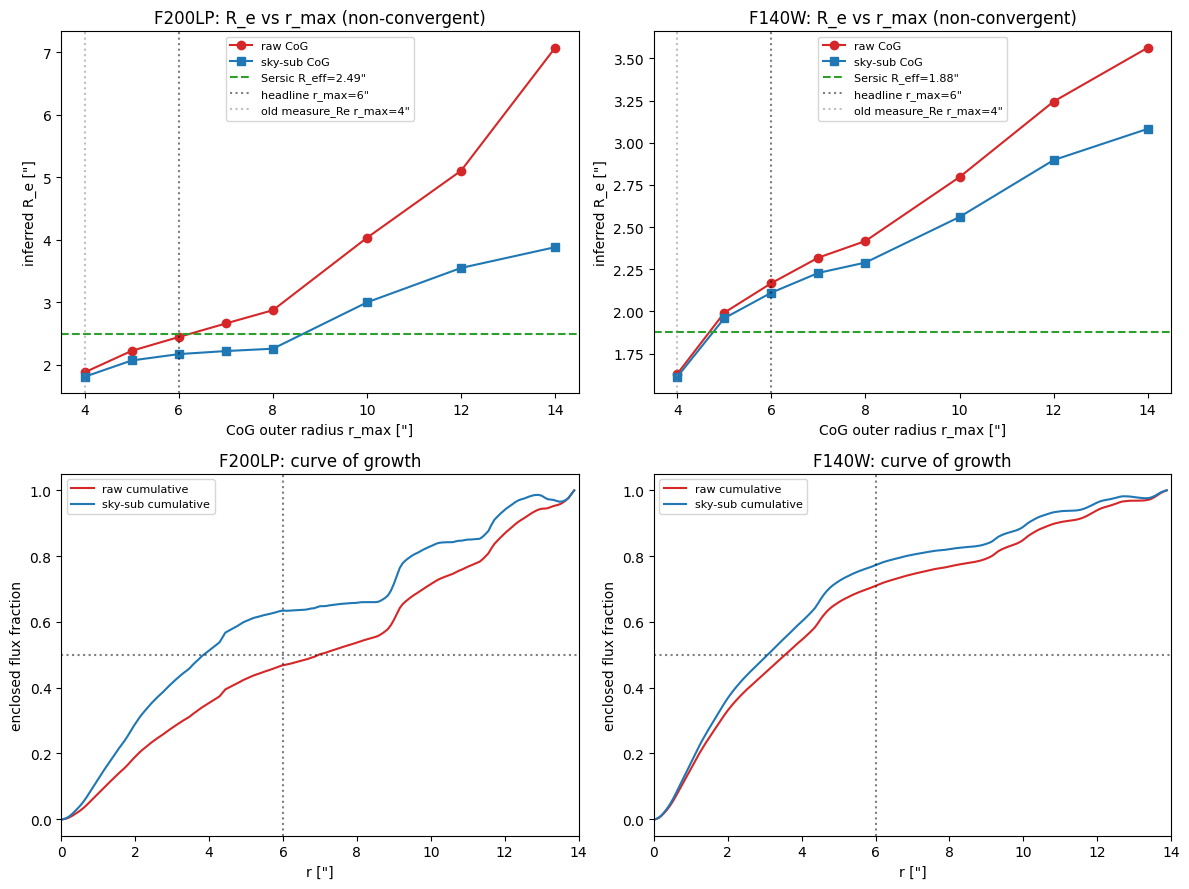

In [5]:
from scipy.integrate import cumulative_trapezoid
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, b in enumerate(BANDS):
    d = imgs[b]; xc, yc = d['cen_centroid']
    yy, xx = np.mgrid[:d['img'].shape[0], :d['img'].shape[1]]
    r = np.hypot(xx-xc, yy-yc)*d['pscale']
    ax = axes[0, col]; rows = conv[b]['rows']
    ax.plot(rows[:,0], rows[:,1], 'o-', label='raw CoG', color='C3')
    ax.plot(rows[:,0], rows[:,2], 's-', label='sky-sub CoG', color='C0')
    ax.axhline(ser_re[b], ls='--', color='C2', label=f'Sersic R_eff={ser_re[b]:.2f}\"')
    ax.axvline(6.0, ls=':', color='k', alpha=0.5, label='headline r_max=6\"')
    ax.axvline(4.0, ls=':', color='gray', alpha=0.5, label='old measure_Re r_max=4\"')
    ax.set_xlabel('CoG outer radius r_max [\"]'); ax.set_ylabel('inferred R_e [\"]')
    ax.set_title(f'{b}: R_e vs r_max (non-convergent)'); ax.legend(fontsize=8)
    edges = np.arange(0, 14, 0.08); rm, Im, Isky = [], [], []
    for j in range(len(edges)-1):
        ann = (r>=edges[j])&(r<edges[j+1])&~d['mask']
        if ann.sum()==0: continue
        rm.append(0.5*(edges[j]+edges[j+1])); Im.append(np.mean(d['img'][ann]))
        Isky.append(np.mean(d['img'][ann]-conv[b]['sky']))
    rm=np.array(rm)
    cum_raw = cumulative_trapezoid(np.array(Im)*2*np.pi*rm, rm, initial=0)
    cum_sky = cumulative_trapezoid(np.array(Isky)*2*np.pi*rm, rm, initial=0)
    ax = axes[1, col]
    ax.plot(rm, cum_raw/cum_raw[-1], color='C3', label='raw cumulative')
    ax.plot(rm, cum_sky/cum_sky[-1], color='C0', label='sky-sub cumulative')
    ax.axhline(0.5, ls=':', color='k', alpha=0.5); ax.axvline(6.0, ls=':', color='k', alpha=0.5)
    ax.set_xlabel('r [\"]'); ax.set_ylabel('enclosed flux fraction')
    ax.set_title(f'{b}: curve of growth'); ax.legend(fontsize=8); ax.set_xlim(0, 14)
plt.tight_layout()
Path('results/figures').mkdir(parents=True, exist_ok=True)
fig.savefig('results/figures/nb14_cog_reconciliation.png', dpi=120, bbox_inches='tight')
print('saved results/figures/nb14_cog_reconciliation.png')

## 4. Conclusion

- **Reconciliation (the asked question):** the two CoG algorithms are the *same algorithm* up to
  `r_max`. measure_Re capped at 4.0" (F200LP); final_sigma_e integrates to 6.0". Matched, they agree
  to <0.04" (residual = centroid_2dg vs fixed-RA/Dec center). **`measure_Re.hst_Re` now defaults to
  `r_max_arcsec=6.0`** so the diagnostic reconciles with the headline by default.
- **Canonical for the headline:** `final_sigma_e.curve_of_growth` at r_max=6" -> R_e = 2.305" (unchanged).
- **New flag (honest):** a raw CoG R_e is r_max-sensitive and non-convergent; the headline 2.305"
  is at the upper end of a 2.1-2.5" method family (sky-sub CoG ~2.14", Sersic ~2.18"). **R_e
  systematic ~ +-0.1-0.2" (~5-9%).** Not folded into the headline here because it would shift the
  sigma_e aperture and M* -- flagged for a user decision (a 2-component-Sersic or PSF-deconvolved R_e
  would be the robust replacement).

In [6]:
np.savez('results/Re_cog_reconciliation.npz',
    bands=np.array(BANDS),
    F200LP_re_mre_4=mre.hst_Re('F200LP', r_max_arcsec=4.0)['Re'],
    F200LP_re_mre_6=mre.hst_Re('F200LP', r_max_arcsec=6.0)['Re'],
    F200LP_re_fse_6=fse.curve_of_growth(imgs['F200LP']['img'], imgs['F200LP']['cen_centroid'],
                                        imgs['F200LP']['pscale'], mask=imgs['F200LP']['mask'], r_max=6.0),
    convergence_F200LP=conv['F200LP']['rows'], convergence_F140W=conv['F140W']['rows'],
    sersic_reff=np.array([ser_re[b] for b in BANDS]),
    headline_mean_raw=hl_raw, skysub_mean=hl_sky, sersic_mean=hl_ser,
    re_systematic_arcsec=re_sys)
print('wrote results/Re_cog_reconciliation.npz')
print(f'\nR_e = 2.305\" (headline, raw CoG r_max=6\") +- {re_sys:.2f}\" (method systematic)')

wrote results/Re_cog_reconciliation.npz

R_e = 2.305" (headline, raw CoG r_max=6") +- 0.08" (method systematic)
